## **<font color="red">InMemoryStore: No De-Duplication</font>** 
- No memory use
- Only to create memory
- Take user message and decide that there is some memory or not. If yes then put in memory store.

In [1]:
from typing import List
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage
from langchain_ollama import ChatOllama
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
import uuid
from pydantic import BaseModel, Field


# =========================
# 1. Initialize LLMs
# =========================

llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0.5,
)

store = InMemoryStore()

# Use NON-reasoning model for extraction
extractor_llm = ChatOllama(
    model="qwen3:1.7b",
    temperature=0.5
)

class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW should be stored. False if duplicate/already known.")

class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.
CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=True ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=False.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""


In [2]:
# =========================
# 2. Memory Node
# =========================

def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    # A. Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B. Latest user message
    last_msg = state["messages"][-1].content

    # C. LLM extracts memory + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": last_msg},
        ]
    )

    # Debug (optional)
    # print("Decision:", decision)

    # D. Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}



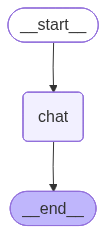

In [3]:
# =========================
# 3. Build Graph
# =========================

builder = StateGraph(MessagesState)

builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [7]:
# =========================
# 4. Demo
# =========================

config = {"configurable": {"user_id": "u1"}}

response = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Vikas"}]}, config)
print("Assistant: ", response["messages"][-1].content)

response = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]}, config)
print("Assistant: ", response["messages"][-1].content)

response = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming is Python"}]}, config)
print("Assistant: ", response["messages"][-1].content)

items = store.search(("user", "u1", "details"))

print("\nStored Memories:")
for item in items:
    print("-", item.value["data"])
print("\n")


Assistant:  Noted.
Assistant:  Noted.
Assistant:  Noted.

Stored Memories:
- User is a teacher of AI on YouTube.
- Python is their favorite programming language.
- Hi my name is Vikas
- Vikas is a teacher of AI on YouTube.
- Python is Vikas's favorite programming language.




In [8]:
# =========================
# 5. Problem of De-Duplication
# =========================

response = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Vikas"}]}, config)
print("Assistant: ", response["messages"][-1].content)

response = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]}, config)
print("Assistant: ", response["messages"][-1].content)

response = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming is Python"}]}, config)
print("Assistant: ", response["messages"][-1].content)

items = store.search(("user", "u1", "details"))

print("\nStored Memories:")
for item in items:
    print("-", item.value["data"])
print("\n")


Assistant:  Noted.
Assistant:  Noted.
Assistant:  Noted.

Stored Memories:
- User is a teacher of AI on YouTube.
- Python is their favorite programming language.
- Hi my name is Vikas
- Vikas is a teacher of AI on YouTube.
- Python is Vikas's favorite programming language.




## **Full Script**

In [6]:
from typing import List
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.messages import SystemMessage
from langchain_ollama import ChatOllama
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
import uuid
from pydantic import BaseModel, Field


# =========================
# 1. Initialize LLMs
# =========================

llm = ChatOllama(
    model="llama3.2:3b",
    temperature=0.5,
)

store = InMemoryStore()

# Use NON-reasoning model for extraction
extractor_llm = ChatOllama(
    model="qwen3:1.7b",
    temperature=0.5
)

class MemoryItem(BaseModel):
    text: str = Field(description="Atomic user memory as a short sentence")
    is_new: bool = Field(description="True if this memory is NEW should be stored. False if duplicate/already known.")

class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[MemoryItem] = Field(default_factory=list, description="Atomic user memories to store")

memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.
CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=True ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=False.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""


# =========================
# 2. Memory Node
# =========================

def chat_creates_memory_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")

    # A. Load existing memories
    existing_items = store.search(namespace)
    existing_texts = [it.value.get("data", "") for it in existing_items if it.value.get("data")]
    user_details_content = "\n".join(f"- {t}" for t in existing_texts) if existing_texts else "(empty)"

    # B. Latest user message
    last_msg = state["messages"][-1].content

    # C. LLM extracts memory + marks new vs duplicate
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(content=MEMORY_PROMPT.format(user_details_content=user_details_content)),
            {"role": "user", "content": last_msg},
        ]
    )

    # Debug (optional)
    # print("Decision:", decision)

    # D. Store ONLY new memories
    if decision.should_write:
        for mem in decision.memories:
            if mem.is_new:
                store.put(namespace, str(uuid.uuid4()), {"data": mem.text})

    return {"messages": [{"role": "assistant", "content": "Noted."}]}


# =========================
# 3. Build Graph
# =========================

builder = StateGraph(MessagesState)

builder.add_node("chat", chat_creates_memory_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)


# =========================
# 4. Demo
# =========================
print("Demonstration: ")

config = {"configurable": {"user_id": "u1"}}

response = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Vikas"}]}, config)
print("Assistant: ", response["messages"][-1].content)

response = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]}, config)
print("Assistant: ", response["messages"][-1].content)

response = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming is Python"}]}, config)
print("Assistant: ", response["messages"][-1].content)

items = store.search(("user", "u1", "details"))

print("\nStored Memories:")
for item in items:
    print("-", item.value["data"])
print("\n"*2)


# =========================
# 5. Solution of De-Duplication
# =========================
print("Solution of De-Duplicaiton: ")

response = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Vikas"}]}, config)
print("Assistant: ", response["messages"][-1].content)

response = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]}, config)
print("Assistant: ", response["messages"][-1].content)

response = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming is Python"}]}, config)
print("Assistant: ", response["messages"][-1].content)

items = store.search(("user", "u1", "details"))

print("\nStored Memories:")
for item in items:
    print("-", item.value["data"])
print("\n"*2)


Demonstration: 
Assistant:  Noted.
Assistant:  Noted.
Assistant:  Noted.

Stored Memories:
- User is a teacher of AI on YouTube.
- Python is their favorite programming language.



Solution of De-Duplicaiton: 
Assistant:  Noted.
Assistant:  Noted.
Assistant:  Noted.

Stored Memories:
- User is a teacher of AI on YouTube.
- Python is their favorite programming language.
- Hi my name is Vikas



